# Severity: Gamma-benchmark for kostnad per registrert egen-skade

Notebooken bruker bare utviklingsårene 2022–2023. 2024 leses aldri. Målet er
en kort og etterprøvbar Gamma-benchmark med samme CV-struktur som frekvens.

In [49]:
import re

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_tweedie_deviance
from sklearn.model_selection import GroupKFold

from core_glm_scripts.glm_core import (
    cross_validate_glm,
    fit_glm,
    glm_spec,
    prepare_design_frame,
)
from core_glm_scripts.model_data import (
    assert_development_years,
    build_development_frames,
)
from src_severity import severity_descriptives
from src_severity.severity_data import build_severity_inputs, summarize_severity_selection

SEED = 100
N_FOLDS = 5
GAMMA_FAMILY = sm.families.Gamma(sm.families.links.Log())
GAMMA_POWER = 2
FIT_SETTINGS = {"maxiter": 200, "tol": 1e-8}

## 1. Datagrunnlag

Vi avgrenser og klargjør bare utviklingsdata. Responsen er gjennomsnittlig
kostnad per registrert skade, og `property_claims` er Gamma-modellens
skadeantallsvekt. Dette tilsvarer en arbeidsantakelse om at et poliseår med
flere skader gir mer presis informasjon om underliggende severity.

In [50]:
frames = build_development_frames()
development = frames["development"]
assert_development_years(development)

severity_inputs = build_severity_inputs(development)
severity_frame = severity_inputs["severity_frame"]
severity_frame["seat_category"] = np.select(
    [severity_frame["seats"].lt(5), severity_frame["seats"].eq(5)],
    ["<5", "=5"],
    default=">5",
)

assert len(severity_frame) == 5_698
assert severity_frame["insured_id"].nunique() == 5_323
assert severity_frame["property_claims"].sum() == 9_979

display(summarize_severity_selection(severity_inputs["model_frame"], severity_frame))

,Poliseår i modellpopulasjonen,Sum eksponering,Sum registrerte skader,Positive skadeår (severity-utvalg),Unike insured_id i severity-utvalget,Sum skader i severity-utvalget,Skadevektet snittseverity (EUR),Utelatte nær-null-poliseår,Registrerte skader i utelatte år
0,55246,37126.013699,9989,5698,5323,9979,872.64457,9,10


## 2. Validering

For hvert poliseår $i$ modellerer vi

$$
\bar X_i \sim \operatorname{Gamma}(\mu_i, \phi/N_i),\qquad
\log\mu_i = \beta_0 + \sum_j\beta_jx_{ij}.
$$

Her er $\bar X_i$ gjennomsnittskostnad og $N_i$ antall registrerte skader.
Gamma-deviance beregnes out-of-fold og vektes med $N_i$. Fem gruppefolder på
`insured_id` hindrer at samme forsikrede finnes i både trening og validering.

In [51]:
group_kfold = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_folds = [
    {
        "fold": f"gruppe_{number + 1}",
        "train_index": severity_frame.index[train_positions],
        "val_index": severity_frame.index[val_positions],
    }
    for number, (train_positions, val_positions) in enumerate(
        group_kfold.split(severity_frame, groups=severity_frame["insured_id"])
    )
]

## 3. Modellspesifikasjoner

Kjernen er den eksisterende severity-modellen: produkt, år, kommunetype,
aldersspline og log-bilverdi. Kandidatene nedenfor er bare alternative
funksjonsformer eller ett tillegg om gangen. Ingen kandidat får særregler.

In [52]:
BASE_LEVELS = {
    "policy_type": "COMP_E",
    "year": 2022,
    "municipality_type": "I",
    "circulation_area": "U",
    "seat_category": "=5",
    "fuel_type": "D",
    "business_type": "NB",
    "payment_frequency": "A",
}
CORE_PREDICTORS = [
    "policy_type",
    "year",
    "municipality_type",
    "driver_age",
    "log_vehicle_value",
]


def spline(column, df=3):
    """Sentrert naturlig kubisk spline som ett patsy-ledd."""
    return f"cr({column}, df={df}, constraints='center')"


def raw_columns(terms):
    """Hent råkolonnene som imputasjonen trenger fra formelleddene."""
    return [
        re.match(r"cr\((\w+)", term)[1] if term.startswith("cr(") else term
        for term in terms
    ]


def build_severity_specification(name, predictors, spline_terms=()):
    """Bygg én Gamma-spesifikasjon fra råprediktorer og valgte spliner."""
    spline_map = dict(spline_terms)
    terms = [
        spline(column, spline_map[column]) if column in spline_map else column
        for column in predictors
    ]
    return glm_spec(
        name,
        terms,
        "average_severity",
        severity_frame,
        GAMMA_FAMILY,
        "property_claims",
        GAMMA_POWER,
        required_columns=raw_columns(terms),
        base_level_overrides=BASE_LEVELS,
    )


BASE_SPLINES = [("driver_age", 3)]

## 4. Sammenligning og valg

En kandidat velges bare dersom den har lavere pooled, skadeantallsvektet
OOF Gamma-deviance enn foreldremodellen, lavere deviance i minst fire av fem
folder og gyldig fit i alle folder. Dette er samme regel for funksjonsform,
tilleggsvariabler og ablasjon; antall parametere gir ingen særregel.

In [53]:
specifications = {
    "kjernevariabler": build_severity_specification(
        "kjernevariabler", CORE_PREDICTORS, BASE_SPLINES
    )
}
cv_results = {
    "kjernevariabler": cross_validate_glm(
        specifications["kjernevariabler"], severity_frame, cv_folds, fit_kwargs=FIT_SETTINGS
    )
}


def select_stage(parent_name, candidate_names):
    """Test kandidater mot én forelder med den felles treleddsregelen."""
    parent_scores = cv_results[parent_name]["scores"].set_index("fold")
    parent_oof = mean_tweedie_deviance(
        severity_frame["average_severity"], cv_results[parent_name]["oof"],
        sample_weight=severity_frame["property_claims"], power=GAMMA_POWER,
    )
    rows = []
    for name in candidate_names:
        candidate = cv_results[name]
        is_valid = candidate["valid"] and candidate["oof"].notna().all()
        candidate_scores = candidate["scores"]
        gain = (
            parent_scores["val_deviance"] - candidate_scores.set_index("fold")["val_deviance"]
            if "val_deviance" in candidate_scores else pd.Series(dtype=float)
        )
        oof_deviance = (
            mean_tweedie_deviance(
                severity_frame["average_severity"], candidate["oof"],
                sample_weight=severity_frame["property_claims"], power=GAMMA_POWER,
            ) if is_valid else np.nan
        )
        rows.append({
            "modell": name,
            "oof_deviance": oof_deviance,
            "lavere_oof": bool(is_valid and oof_deviance < parent_oof),
            "bedre_4_av_5": gain.gt(0).sum() >= 4,
            "gyldig_i_alle_folder": is_valid,
            "cv_feil": candidate["error"] or "",
        })
    table = pd.DataFrame(rows).set_index("modell")
    criteria = ["lavere_oof", "bedre_4_av_5", "gyldig_i_alle_folder"]
    eligible = table.loc[table[criteria].all(axis=1)]
    selected = eligible["oof_deviance"].idxmin() if len(eligible) else parent_name
    return selected, table

### 4.1 Funksjonsform

Alders- og bilverdieffekten utfordres med de eksisterende funksjonsformene.
Bare den beste kvalifiserte kandidaten går videre.

In [54]:
form_candidates = {
    "alder_lineær": build_severity_specification("alder_lineær", CORE_PREDICTORS, []),
    "alder_spline_df2": build_severity_specification(
        "alder_spline_df2", CORE_PREDICTORS, [("driver_age", 2)]
    ),
    "alder_spline_df4": build_severity_specification(
        "alder_spline_df4", CORE_PREDICTORS, [("driver_age", 4)]
    ),
    "bilverdi_spline": build_severity_specification(
        "bilverdi_spline", CORE_PREDICTORS,
        [("driver_age", 3), ("log_vehicle_value", 3)],
    ),
}
specifications.update(form_candidates)
cv_results.update({
    name: cross_validate_glm(spec, severity_frame, cv_folds, fit_kwargs=FIT_SETTINGS)
    for name, spec in form_candidates.items()
})
form_model_name, form_selection = select_stage("kjernevariabler", list(form_candidates))
display(form_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
alder_lineær,0.7260,True,True,True,
alder_spline_df2,0.7268,True,True,True,
alder_spline_df4,0.7275,False,False,True,
bilverdi_spline,0.7283,False,False,True,


### 4.2 Geografi

Kommunetype kan erstattes av kjøresone eller suppleres med kjøresone. Begge
behandles som vanlige kandidater mot modellen fra forrige trinn.

In [55]:
def spline_terms_from_specification(specification):
    """Les valgte splinegrader fra spesifikasjonen."""
    terms = []
    for term in specification["x"]:
        match = re.match(r"cr\((\w+), df=(\d+)", term)
        if match:
            terms.append((match.group(1), int(match.group(2))))
    return terms


current_predictors = specifications[form_model_name]["required_columns"]
current_splines = spline_terms_from_specification(specifications[form_model_name])
geography_candidates = {
    "kjerne_med_kjøresone": build_severity_specification(
        "kjerne_med_kjøresone",
        ["circulation_area" if column == "municipality_type" else column for column in current_predictors],
        current_splines,
    ),
    "kjerne_med_begge_geografier": build_severity_specification(
        "kjerne_med_begge_geografier", [*current_predictors, "circulation_area"], current_splines
    ),
}
specifications.update(geography_candidates)
cv_results.update({
    name: cross_validate_glm(spec, severity_frame, cv_folds, fit_kwargs=FIT_SETTINGS)
    for name, spec in geography_candidates.items()
})
geography_model_name, geography_selection = select_stage(form_model_name, list(geography_candidates))
display(geography_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
kjerne_med_kjøresone,0.7224,True,True,True,
kjerne_med_begge_geografier,0.7236,True,True,True,


### 4.3 Tilleggsvariabler

Én forhåndsdefinert utvidelse testes om gangen. Ytelse utfordres både lineært
og som spline; de øvrige variablene bruker sin eksisterende definisjon.

In [56]:
current_predictors = specifications[geography_model_name]["required_columns"]
current_splines = spline_terms_from_specification(specifications[geography_model_name])
additional_candidates = {
    "med_ytelse_lineær": build_severity_specification(
        "med_ytelse_lineær", [*current_predictors, "performance_hp_per_tonne"], current_splines
    ),
    "med_ytelse_spline": build_severity_specification(
        "med_ytelse_spline", [*current_predictors, "performance_hp_per_tonne"],
        [*current_splines, ("performance_hp_per_tonne", 3)],
    ),
    "med_seter": build_severity_specification("med_seter", [*current_predictors, "seat_category"], current_splines),
    "med_drivstoff": build_severity_specification("med_drivstoff", [*current_predictors, "fuel_type"], current_splines),
    "med_forretningstype": build_severity_specification("med_forretningstype", [*current_predictors, "business_type"], current_splines),
    "med_betalingsfrekvens": build_severity_specification("med_betalingsfrekvens", [*current_predictors, "payment_frequency"], current_splines),
    "med_bilmerke": build_severity_specification("med_bilmerke", [*current_predictors, "vehicle_brand_pooled"], current_splines),
}
specifications.update(additional_candidates)
cv_results.update({
    name: cross_validate_glm(spec, severity_frame, cv_folds, fit_kwargs=FIT_SETTINGS)
    for name, spec in additional_candidates.items()
})
selected_model_name, additional_selection = select_stage(geography_model_name, list(additional_candidates))
display(additional_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
med_ytelse_lineær,0.7231,False,False,True,
med_ytelse_spline,0.7248,False,False,True,
med_seter,0.7217,True,False,True,
med_drivstoff,0.7231,False,False,True,
med_forretningstype,0.7218,True,False,True,
med_betalingsfrekvens,0.7227,False,False,True,
med_bilmerke,0.7224,True,False,True,


### 4.4 Ablasjon

Vi tester å fjerne én ikke-beskyttet råprediktor om gangen fra modellen som
nå er valgt. En fjerning beholdes bare når den oppfyller den samme
treleddsregelen, og prosessen gjentas til ingen kvalifisert fjerning gjenstår.

In [57]:
def ablate_model(start_name):
    """Fjern én kvalifisert variabel om gangen med felles CV-regel."""
    current_name = start_name
    removed = []
    protected = {"policy_type", "year"}
    while True:
        current_predictors = specifications[current_name]["required_columns"]
        current_splines = spline_terms_from_specification(specifications[current_name])
        removable = [column for column in current_predictors if column not in protected]
        if not removable:
            return current_name, removed
        candidates = {}
        for column in removable:
            name = f"{current_name}_uten_{column}"
            remaining = [item for item in current_predictors if item != column]
            terms = [item for item in current_splines if item[0] in remaining]
            candidates[name] = build_severity_specification(name, remaining, terms)
        specifications.update(candidates)
        cv_results.update({
            name: cross_validate_glm(spec, severity_frame, cv_folds, fit_kwargs=FIT_SETTINGS)
            for name, spec in candidates.items()
        })
        next_name, table = select_stage(current_name, list(candidates))
        table["fjernet_variabel"] = [name.rsplit("_uten_", 1)[1] for name in table.index]
        display(table.round(4))
        if next_name == current_name:
            return current_name, removed
        removed.append(next_name.rsplit("_uten_", 1)[1])
        current_name = next_name


final_model_name, removed_predictors = ablate_model(selected_model_name)
final_specification = specifications[final_model_name]
print("Valgt severity-modell:", final_model_name)
print("Fjernet i ablasjon:", ", ".join(removed_predictors) or "ingen")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil,fjernet_variabel
modell,,,,,,
kjerne_med_kjøresone_uten_circulation_area,0.7246,False,False,True,,circulation_area
kjerne_med_kjøresone_uten_driver_age,0.7214,True,False,True,,driver_age
kjerne_med_kjøresone_uten_log_vehicle_value,0.7283,False,False,True,,log_vehicle_value


Valgt severity-modell: kjerne_med_kjøresone
Fjernet i ablasjon: ingen


## 5. Storskader

Figuren viser kostnadskonsentrasjon og fordelingen av gjennomsnittskostnad
per skadeår. Den er diagnostisk: skadeårene er ikke enkeltskader, og verken
terskler eller kapping brukes i kandidatsøket.

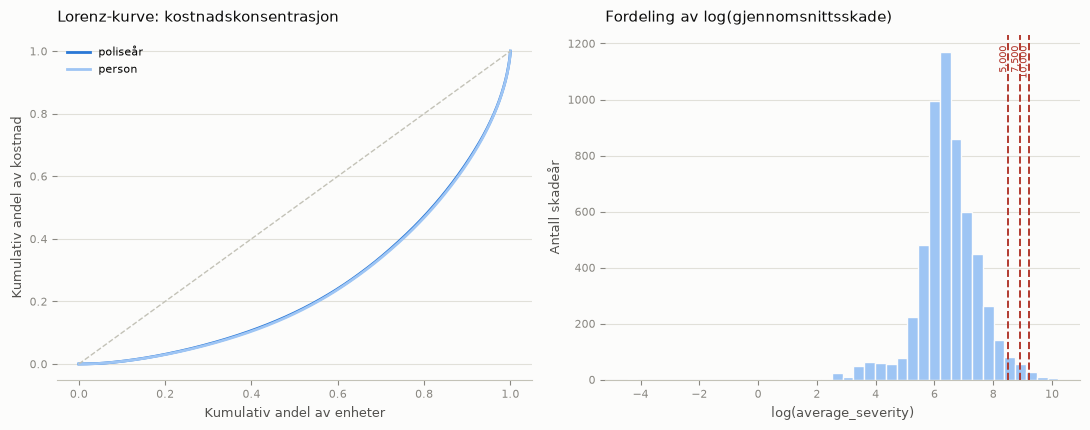

In [58]:
display(severity_descriptives.plot_cost_concentration(severity_frame))

## 6. Koeffisienttabell for valgt modell

Koeffisientene estimeres på hele utviklingsutvalget med cluster-robuste
standardfeil på `insured_id`. De beskriver justerte sammenhenger i disse
utviklingsdataene, ikke kausale effekter.

In [59]:
final_design = prepare_design_frame(severity_frame, severity_frame, final_specification["required_columns"])
final_fit = fit_glm(
    final_specification, final_design, cluster_groups=final_design["insured_id"], fit_kwargs=FIT_SETTINGS
)
confidence = final_fit.conf_int()
coefficient_table = pd.DataFrame({
    "ledd": final_fit.params.index,
    "koeffisient": final_fit.params.to_numpy(),
    "SE_cluster": final_fit.bse.to_numpy(),
    "relativitet": np.exp(final_fit.params.to_numpy()),
    "relativitet_lav": np.exp(confidence[0].to_numpy()),
    "relativitet_høy": np.exp(confidence[1].to_numpy()),
})
display(coefficient_table.round(3))

,ledd,koeffisient,SE_cluster,relativitet,relativitet_lav,relativitet_høy
0,Intercept,4.932,0.380,138.702,65.875,292.042
1,"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",-0.400,0.031,0.670,0.631,0.712
2,"C(year, Treatment(2022))[T.2023]",-0.085,0.032,0.919,0.862,0.979
3,"C(circulation_area, Treatment('U'))[T.R]",0.104,0.034,1.110,1.038,1.185
4,driver_age,-0.001,0.001,0.999,0.996,1.001
5,log_vehicle_value,0.199,0.037,1.221,1.136,1.312


## 7. Konkurrerende modeller

Tabellen viser valgt modell og de tre nærmeste gyldige alternativene målt ved
OOF Gamma-deviance. `spesifikasjon` gjør sammenligningen mulig å lese uten å
slå opp modell-ID-en. OOF-resultatene er utviklingsresultater og inkluderer
seleksjonsoptimisme; de er ikke en evaluering på 2024.

In [60]:
def summarize_candidate(name, result):
    """Samle OOF-mål og spesifikasjon for én gyldig severity-kandidat."""
    oof_deviance = mean_tweedie_deviance(
        severity_frame["average_severity"], result["oof"],
        sample_weight=severity_frame["property_claims"], power=GAMMA_POWER,
    )
    return {
        "modell": name,
        "spesifikasjon": specifications[name]["formula"],
        "oof_deviance": oof_deviance,
        "parametere": int(result["scores"]["n_params"].mean()),
    }


candidate_metrics = pd.DataFrame([
    summarize_candidate(name, result)
    for name, result in cv_results.items()
    if result["valid"] and result["oof"].notna().all()
]).set_index("modell")
competitor_names = [final_model_name] + [
    name for name in candidate_metrics.sort_values("oof_deviance").index
    if name != final_model_name
][:3]
decision_table = candidate_metrics.loc[competitor_names]
display(decision_table.round(4))

,spesifikasjon,oof_deviance,parametere
modell,,,
kjerne_med_kjøresone,"average_severity ~ C(policy_type, Treatment('C...",0.7224,6
kjerne_med_kjøresone_uten_driver_age,"average_severity ~ C(policy_type, Treatment('C...",0.7214,5
med_seter,"average_severity ~ C(policy_type, Treatment('C...",0.7217,8
med_forretningstype,"average_severity ~ C(policy_type, Treatment('C...",0.7218,7


## 8. Statsmodels-sammendrag

In [61]:
display(final_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:       average_severity   No. Observations:                 5698
Model:                            GLM   Df Residuals:                     5692
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                          3.1268
Method:                          IRLS   Log-Likelihood:                -46446.
Date:                Fri, 18 Sep 2026   Deviance:                       7182.2
Time:                        20:41:55   Pearson chi2:                 1.78e+04
No. Iterations:                    11   Pseudo R-squ. (CS):            0.02767
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         4.9323      0.380     12.984      0.000       4.188       5.677
C(policy_type, Treatment('COMP_E'))[T.COMP_N]    -0.3997      0.031    -12.956      0.000      -0.460      -0.339
C(year, Treatment(2022))[T.2023]                 -0.0850      0.032     -2.620      0.009      -0.149      -0.021
C(circulation_area, Treatment('U'))[T.R]          0.1039      0.034      3.077      0.002       0.038       0.170
driver_age                                       -0.0011      0.001     -0.897      0.370      -0.004       0.001
log_vehicle_value                                 0.1994      0.037      5.418      0.000       0.127       0.271
=================================================================================================================
"""